# 4. Evaluation & Explainability — NSL-KDD Intrusion Detection

**Goal:** understand *why* the model predicts what it predicts, and produce final charts/tables for a report.

**Input:** `train_processed.csv`, `model_comparison.csv`, `confusion_matrix.csv`, `test_predictions.csv` (from notebooks 2 & 3)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_comparison = pd.read_csv("data/model_comparison.csv")
confusion = pd.read_csv("data/confusion_matrix.csv", index_col=0)
preds = pd.read_csv("data/test_predictions.csv")
train = pd.read_csv("data/train_processed.csv")

model_comparison

,model,macro_f1,weighted_f1,novel_attack_detection_rate
0,Logistic Regression,0.6093,0.7821,0.4347
1,Decision Tree,0.5016,0.7121,0.4280
2,Random Forest,0.4738,0.6906,0.1507


## Chart: model comparison

A quick visual makes the Random-Forest-vs-Logistic-Regression finding much clearer than a table alone.

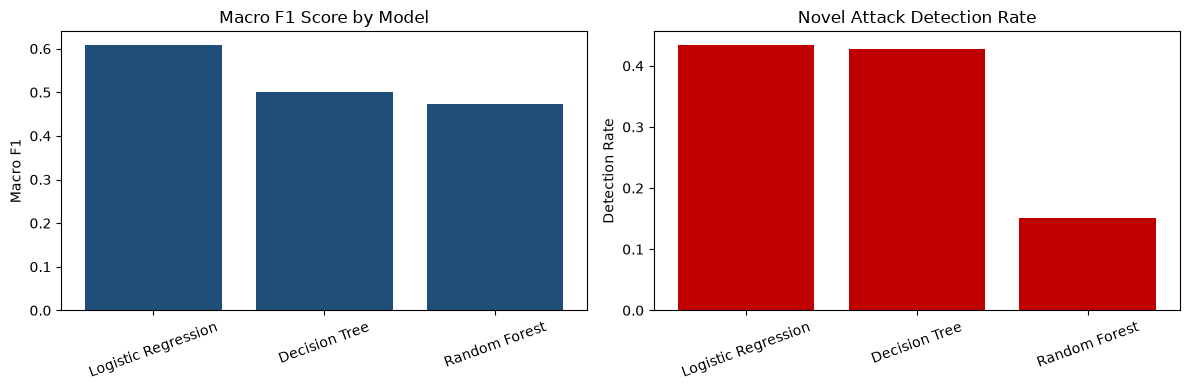

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(model_comparison["model"], model_comparison["macro_f1"], color="#1F4E78")
axes[0].set_title("Macro F1 Score by Model")
axes[0].set_ylabel("Macro F1")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(model_comparison["model"], model_comparison["novel_attack_detection_rate"], color="#C00000")
axes[1].set_title("Novel Attack Detection Rate")
axes[1].set_ylabel("Detection Rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("data/model_comparison_chart.png", dpi=120)
plt.show()

**What to look for:** if Random Forest has a high macro F1 bar but a low novel-detection bar, that's the overfitting story — strong on attacks it trained on, weak on attacks it's never seen.

## Confusion matrix heatmap

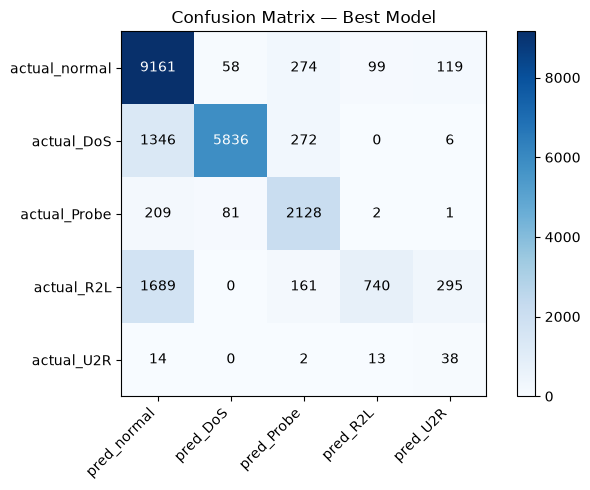

In [3]:
plt.figure(figsize=(7, 5))
plt.imshow(confusion.values, cmap="Blues")
plt.xticks(range(len(confusion.columns)), confusion.columns, rotation=45, ha="right")
plt.yticks(range(len(confusion.index)), confusion.index)
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, confusion.values[i, j], ha="center", va="center",
                  color="white" if confusion.values[i, j] > confusion.values.max()/2 else "black")
plt.title("Confusion Matrix — Best Model")
plt.colorbar()
plt.tight_layout()
plt.savefig("data/confusion_matrix_chart.png", dpi=120)
plt.show()

**How to read it:** a strong model has a bright diagonal (correct predictions) and dark everywhere else. Look at the `R2L` and `U2R` rows — you'll likely see them "leaking" into the `normal` column, meaning the model missed them. That's the known, documented weak spot of this dataset — worth naming honestly rather than hiding.

## Feature importance (using Random Forest, for interpretability)

Even if Logistic Regression won on generalization, Random Forest's feature importances are a clean way to see which raw signals matter most — useful context for any model.

In [4]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

feature_cols = [c for c in train.columns if c not in ["label", "attack_category"]]
X = train[feature_cols]
y = train["attack_category"]

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_depth=20,
                             random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv("data/feature_importance.csv", index=False)
importance_df.head(15)

,feature,importance
1,src_bytes,0.114801
29,dst_host_srv_count,0.084709
2,dst_bytes,0.084678
39,service_enc,0.073916
8,logged_in,0.058375
34,dst_host_serror_rate,0.049418
20,srv_count,0.042481
32,dst_host_same_src_port_rate,0.039660
31,dst_host_diff_srv_rate,0.038595
19,count,0.035752


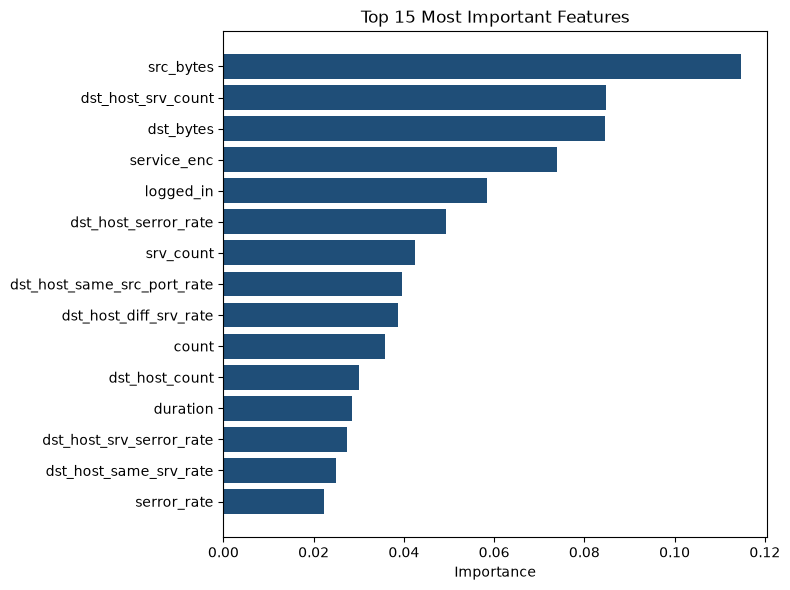

In [5]:
plt.figure(figsize=(8, 6))
top15 = importance_df.head(15).sort_values("importance")
plt.barh(top15["feature"], top15["importance"], color="#1F4E78")
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("data/feature_importance_chart.png", dpi=120)
plt.show()

**What these features mean, in plain terms:**
- `src_bytes` / `dst_bytes` — how much data was sent/received. Attacks often involve unusual data volumes.
- `dst_host_srv_count` — how many connections went to the same service on the same host recently. Spikes here suggest scanning or flooding.
- `logged_in` — whether the connection successfully logged in. Relevant for brute-force/guessing attacks.
- `service` — which network service was accessed (http, ftp, etc.) — some services are attacked far more than others.

## Novel attack type breakdown

Which specific never-seen attack types did we catch, and which did we miss?

In [6]:
novel = preds[preds["is_novel_attack_type"] == 1]

novel_summary = novel.groupby("label").agg(
    occurrences=("label", "size"),
    detected=("predicted_category", lambda x: (x != "normal").sum())
).reset_index()
novel_summary["detection_rate"] = (novel_summary["detected"] / novel_summary["occurrences"]).round(2)
novel_summary = novel_summary.sort_values("occurrences", ascending=False)

novel_summary

,label,occurrences,detected,detection_rate
3,mscan,996,802,0.81
0,apache2,737,217,0.29
5,processtable,685,228,0.33
10,snmpguess,331,3,0.01
7,saint,319,308,0.97
2,mailbomb,293,0,0.00
9,snmpgetattack,178,14,0.08
1,httptunnel,133,6,0.05
4,named,17,7,0.41
6,ps,15,10,0.67


## Summary: what to say about this project

- Trained and compared 3 models on the real NSL-KDD benchmark (125,973 training / 22,544 test records)
- Used **macro F1**, not accuracy, because of severe class imbalance (U2R: 52 training examples vs. normal: 67,343)
- Found that **Random Forest overfit** to training-set attack signatures — it scored well on known attacks but generalized poorly to the 17 attack types never seen during training
- **Logistic Regression generalized better** despite being the simpler model — a genuinely useful, non-obvious finding
- Identified **R2L and U2R as consistently hard categories** across all models — a known, documented limitation of this dataset, not a bug in the approach
- Backed every conclusion with feature importance / coefficients, so findings are explainable to a non-technical stakeholder

This notebook sequence is complete. From here, you can package these results into a report or dashboard (see the earlier `IDS_Report.docx` / Excel dashboard versions), or extend the project — e.g., try SMOTE for the imbalance, or add a fourth model like XGBoost.